In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(color_codes=True)

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path='/content/drive/MyDrive/indian_bus_fare_dataset.csv'
df=pd.read_csv(file_path)
print(df)

                 Agency     Source Destination        Bus Type Travel Date  \
0                RedBus    Kolkata       Delhi  Non-AC Sleeper  2018-09-12   
1           VRL Travels      Delhi     Chennai           Volvo  2017-10-11   
2                RedBus  Hyderabad      Jaipur           Volvo  2023-04-17   
3                RedBus  Ahmedabad       Delhi   Non-AC Seater  2019-08-23   
4                RedBus     Jaipur        Pune  Non-AC Sleeper  2021-01-05   
...                 ...        ...         ...             ...         ...   
499995           RedBus    Lucknow       Delhi      AC Sleeper  2019-06-14   
499996  Parveen Travels    Lucknow       Delhi           Volvo  2024-08-22   
499997  Parveen Travels       Pune      Jaipur      AC Sleeper  2017-06-18   
499998      SRS Travels    Kolkata   Hyderabad      AC Sleeper  2023-04-15   
499999      SRS Travels      Delhi   Bangalore      AC Sleeper  2015-05-10   

        Fare Price (INR)  Total Seats  Duration (hours)  
0    

In [ ]:
df.dtypes

,0
Agency,object
Source,object
Destination,object
Bus Type,object
Travel Date,object
Fare Price (INR),float64
Total Seats,int64
Duration (hours),float64


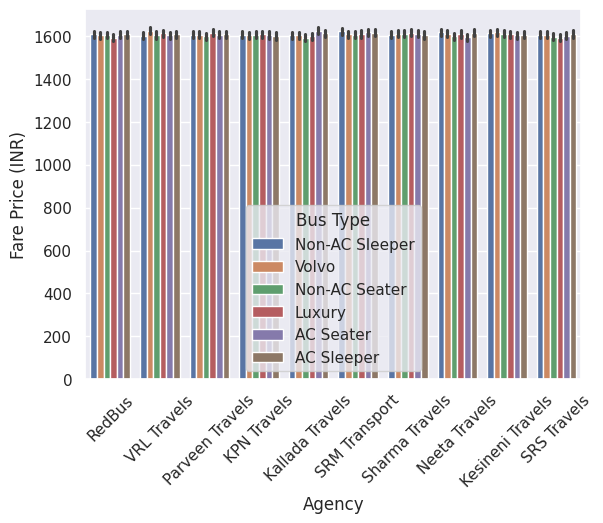

In [ ]:
sns.barplot(data=df, x='Agency', y='Fare Price (INR)', hue='Bus Type')
plt.xticks(rotation=45) # Helps prevent the agency names from overlapping
plt.show()

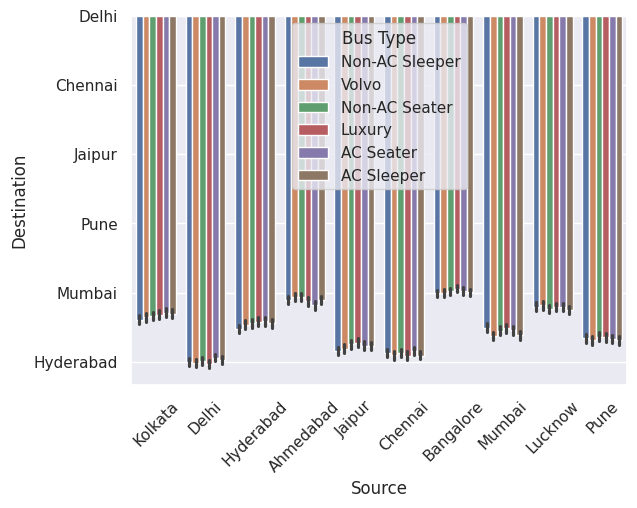

In [ ]:
sns.barplot(data=df, x='Source', y='Destination', hue='Bus Type')
plt.xticks(rotation=45) # Helps prevent the agency names from overlapping
plt.show()

In [ ]:
df['Agency'].unique()

array(['RedBus', 'VRL Travels', 'Parveen Travels', 'KPN Travels',
       'Kallada Travels', 'SRM Transport', 'Sharma Travels',
       'Neeta Travels', 'Kesineni Travels', 'SRS Travels'], dtype=object)

In [ ]:
df['Source'].unique()

array(['Kolkata', 'Delhi', 'Hyderabad', 'Ahmedabad', 'Jaipur', 'Chennai',
       'Bangalore', 'Mumbai', 'Lucknow', 'Pune'], dtype=object)

In [ ]:
df['Destination'].unique()

array(['Delhi', 'Chennai', 'Jaipur', 'Pune', 'Mumbai', 'Hyderabad',
       'Kolkata', 'Lucknow', 'Ahmedabad', 'Bangalore'], dtype=object)

In [ ]:
df['Bus Type'].unique()

array(['Non-AC Sleeper', 'Volvo', 'Non-AC Seater', 'Luxury', 'AC Seater',
       'AC Sleeper'], dtype=object)

In [ ]:
df['Travel Date'].unique()

array(['2018-09-12', '2017-10-11', '2023-04-17', ..., '2020-10-14',
       '2018-06-25', '2015-12-01'], dtype=object)

In [ ]:
df['Fare Price (INR)'].unique()

array([2461.13, 1029.78, 1329.02, ..., 2288.07,  694.84,  884.18])

In [ ]:
df['Total Seats'].unique()

array([50, 31, 28, 39, 38, 30, 44, 25, 34, 22, 35, 43, 20, 45, 37, 47, 48,
       23, 46, 36, 24, 32, 21, 27, 42, 49, 40, 33, 26, 41, 29])

In [ ]:
df['Duration (hours)'].unique()

array([11.9, 14.5,  5.7, 15.3, 12.4,  5.2, 11.3,  7.6, 16.8, 15.8, 15.9,
        6.9, 10.6,  5.9, 15.4, 10.1, 10.7, 12.3,  5.3, 12. ,  8.8,  7.1,
       17.1, 15. , 17.7, 16.1,  9.6,  6.5, 16.6, 14.6, 17.9, 10.5, 14.7,
        7. , 11.2, 11.5,  9.4,  9.1,  9.2, 16.4,  7.2, 17.8,  9.7, 12.1,
        8. ,  6.7, 18. , 11.4, 12.8,  5.5,  7.4,  6.6, 14.8, 11.6, 17.5,
       10.4, 16.5, 16. , 11. , 14.9,  5.8,  7.9,  5.4, 15.5,  9. ,  9.3,
        6.1, 14.2, 15.1, 14.3, 10.8, 13.2, 13.1, 14.1, 16.9, 14. , 12.5,
       12.7, 17. ,  8.6, 12.6,  6.8, 15.2, 16.3,  7.7, 13.8, 17.6, 13.3,
       15.6,  8.7,  6.4,  8.1, 11.7, 17.3,  9.9,  7.3,  7.8, 13.5, 10.2,
       11.8,  6.2,  9.8,  5.6, 15.7, 10.3,  5. ,  8.5,  8.9,  8.3,  5.1,
       17.2, 13.7, 16.2, 13.4, 13.6, 12.2, 17.4, 14.4,  6. ,  8.2, 10.9,
       13.9,  6.3,  8.4, 16.7,  9.5,  7.5, 13. , 11.1, 10. , 12.9])

/tmp/ipykernel_1255/3042746798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Source', order=df['Source'].value_counts().index, palette='magma')


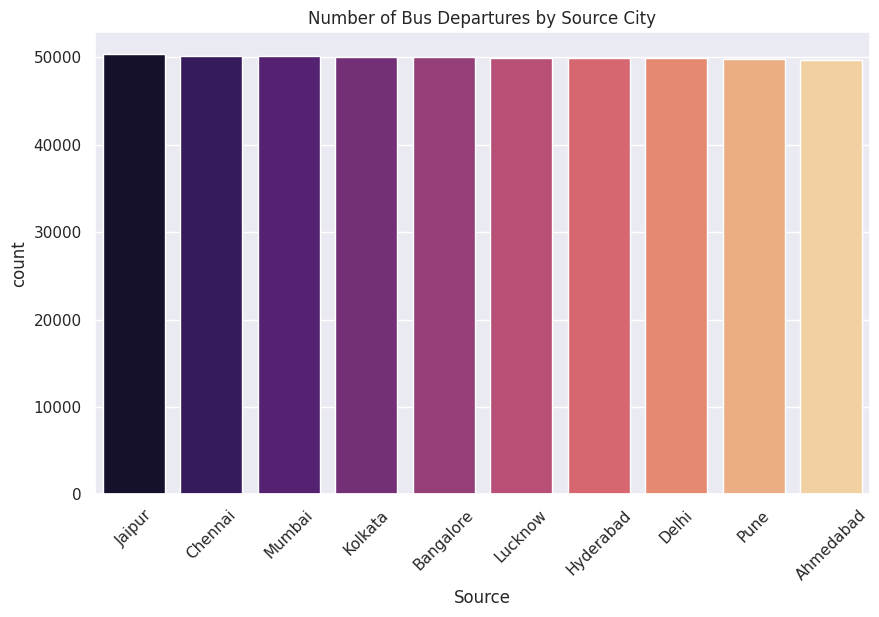

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Source', order=df['Source'].value_counts().index, palette='magma')
plt.title('Number of Bus Departures by Source City')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1255/1539012931.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Agency', y='Fare Price (INR)', estimator='mean', palette='viridis')


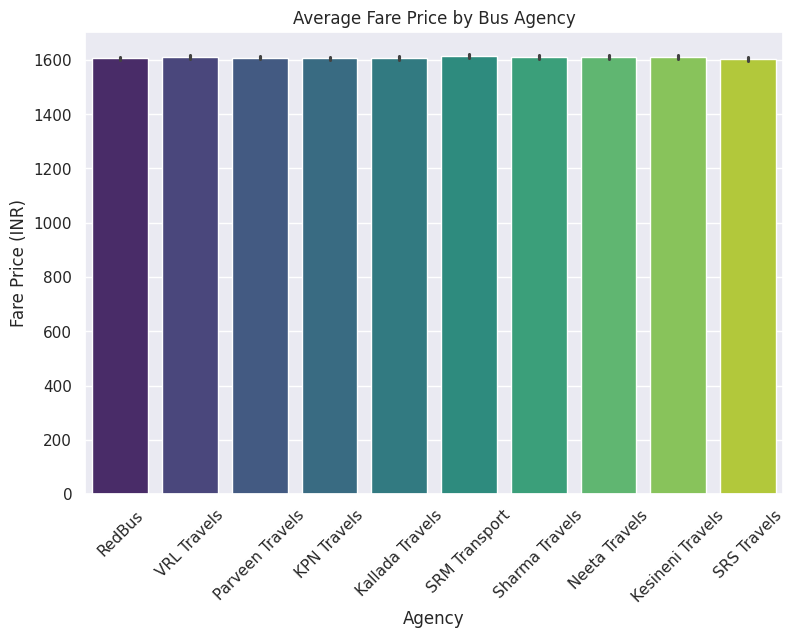

In [ ]:
plt.figure(figsize=(9, 6))
# Using estimator='mean' explicitly calculates the average fare per agency
sns.barplot(data=df, x='Agency', y='Fare Price (INR)', estimator='mean', palette='viridis')
plt.title('Average Fare Price by Bus Agency')
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


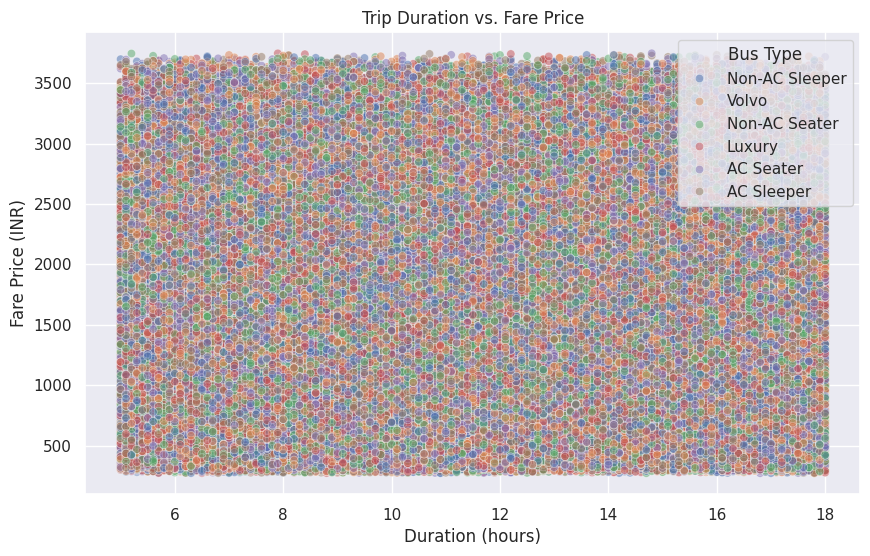

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration (hours)', y='Fare Price (INR)', hue='Bus Type', alpha=0.5)
plt.title('Trip Duration vs. Fare Price')
plt.show()

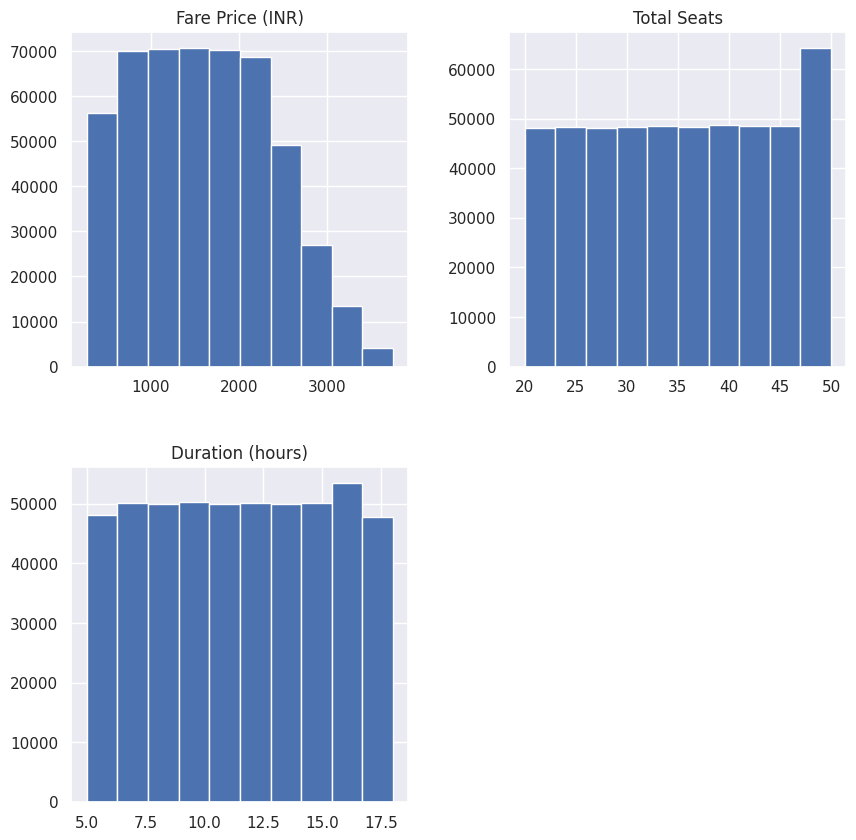

In [ ]:
df.hist(figsize=(10,10))
plt.show()

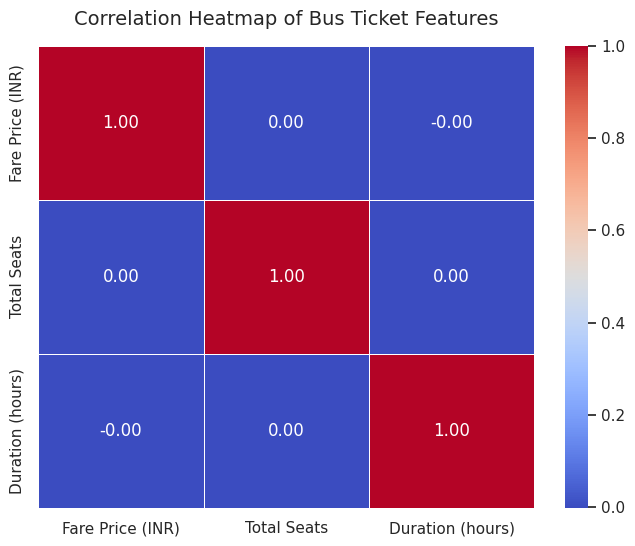

In [ ]:

plt.figure(figsize=(8, 6))


sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)


plt.title('Correlation Heatmap of Bus Ticket Features', fontsize=14, pad=15)
plt.show()


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
data = load_iris()

X = data.data
y = data.target

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# Create model
lr = LogisticRegression()

# Train model
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:

X = df.drop('Fare Price (INR)', axis=1)
y = df['Fare Price (INR)']



In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtree = DecisionTreeRegressor(random_state=0)
dtree.fit(X_train, y_train)

ValueError: could not convert string to float: 'Parveen Travels'

In [ ]:
y_pred = dtree.predict(X_test)

In [ ]:
from sklearn import metrics
import math

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

In [ ]:
from sklearn import metrics
import math
y_pred = rf.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
ada = AdaBoostRegressor(random_state=0)
ada.fit(X_train, y_train)

In [ ]:
from sklearn import metrics
import math
y_pred = ada.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))